In [9]:
from google.colab import files
uploaded = files.upload()

Saving Screenshot 2026-07-21 143017.png to Screenshot 2026-07-21 143017 (1).png


Image Shape: (182, 340)


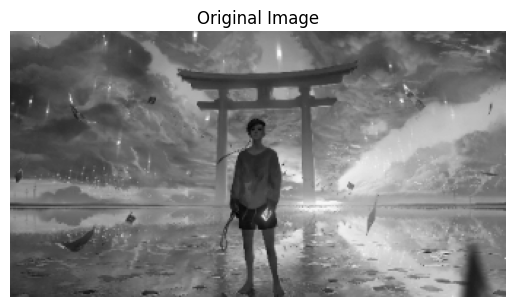

In [14]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

img = cv2.imread('Screenshot 2026-07-21 143017 (1).png', cv2.IMREAD_GRAYSCALE)

if img is None:
    raise Exception("Image not found. Check filename.")

print("Image Shape:", img.shape)

plt.imshow(img, cmap='gray')
plt.title("Original Image")
plt.axis('off')
plt.show()

 # Q1: Histogram Equalization
Objective:
Perform histogram equalization on a sample image matrix.

Procedure:
1. Calculate histogram.
2. Find PDF.
3. Find CDF.
4. Apply equalization formula.
5. Display output image.

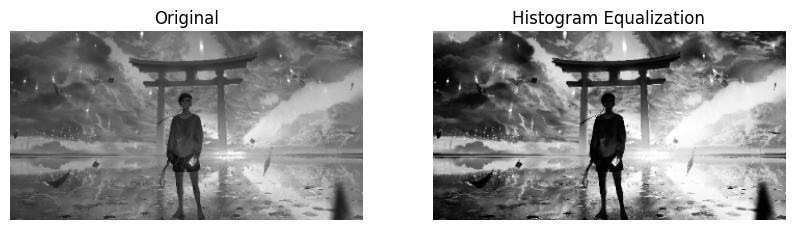

In [15]:
equalized = cv2.equalizeHist(img)

plt.figure(figsize=(10,5))

plt.subplot(1,2,1)
plt.imshow(img,cmap='gray')
plt.title("Original")
plt.axis('off')

plt.subplot(1,2,2)
plt.imshow(equalized,cmap='gray')
plt.title("Histogram Equalization")
plt.axis('off')

plt.show()

Apply negative transformation and logarithmic transformation on a grayscale image.

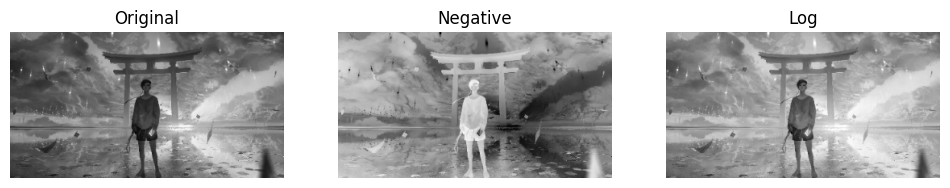

In [16]:
negative = 255 - img

c = 255 / np.log(1 + np.max(img))
log_img = c * np.log(1 + img)
log_img = np.array(log_img,dtype=np.uint8)

plt.figure(figsize=(12,4))

plt.subplot(1,3,1)
plt.imshow(img,cmap='gray')
plt.title("Original")
plt.axis('off')

plt.subplot(1,3,2)
plt.imshow(negative,cmap='gray')
plt.title("Negative")
plt.axis('off')

plt.subplot(1,3,3)
plt.imshow(log_img,cmap='gray')
plt.title("Log")
plt.axis('off')

plt.show()

# Q3: Power-Law (Gamma) Transformation

Objective:
To study the effect of different gamma values on image contrast.

Procedure:
1. Select gamma values.
2. Apply power-law transformation.
3. Observe intensity changes.

Output:
Gamma corrected image matrices.

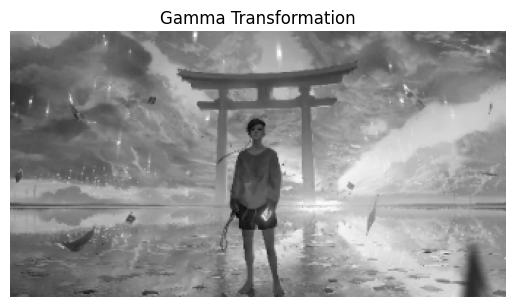

In [17]:
gamma = 0.5

gamma_img = np.array(
    255 * ((img/255) ** gamma),
    dtype=np.uint8
)

plt.imshow(gamma_img,cmap='gray')
plt.title("Gamma Transformation")
plt.axis('off')
plt.show()

# Q4: Piecewise-Linear Contrast Stretching

Objective:
To enhance a low-contrast image using contrast stretching.

Procedure:
1. Define intensity ranges.
2. Apply stretching function.
3. Generate enhanced image.

Output:
Contrast-stretched image matrix.

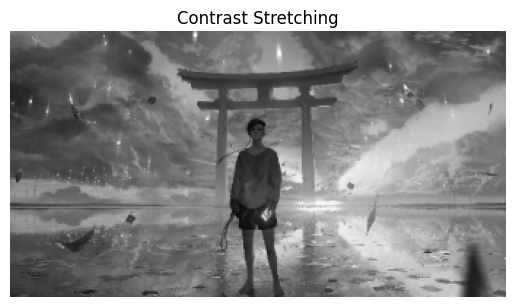

In [18]:
stretched = cv2.normalize(
    img,None,0,255,
    cv2.NORM_MINMAX
)

plt.imshow(stretched,cmap='gray')
plt.title("Contrast Stretching")
plt.axis('off')
plt.show()

# Q5: Mean (Averaging) Filter

Objective:
To smooth an image using a 3x3 averaging kernel.

Procedure:
1. Create averaging mask.
2. Perform convolution.
3. Generate filtered image.

Output:
Smoothed image matrix.

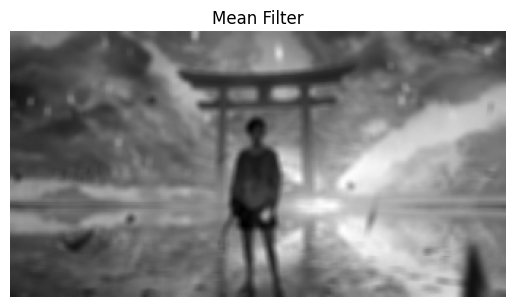

In [19]:
mean_img = cv2.blur(img,(5,5))

plt.imshow(mean_img,cmap='gray')
plt.title("Mean Filter")
plt.axis('off')
plt.show()

# Q6: Median Filter for Noise Removal

Objective:
To remove salt-and-pepper noise using median filtering.

Procedure:
1. Add noise to image.
2. Apply median filter.
3. Compare results.

Output:
Noisy image and filtered image.

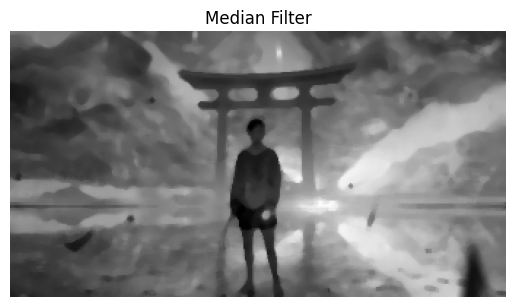

In [20]:
median_img = cv2.medianBlur(img,5)

plt.imshow(median_img,cmap='gray')
plt.title("Median Filter")
plt.axis('off')
plt.show()

# Q7: Laplacian Sharpening

Objective:
To enhance image edges using the Laplacian operator.

Procedure:
1. Apply Laplacian mask.
2. Add result to original image.
3. Generate sharpened image.

Output:
Sharpened image matrix.

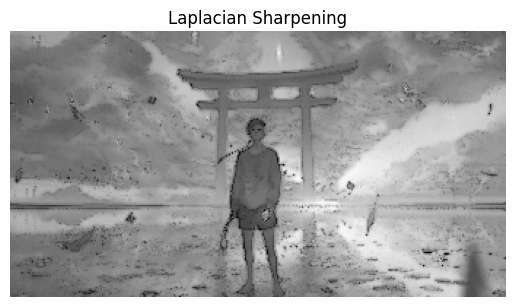

In [21]:
lap = cv2.Laplacian(img,cv2.CV_64F)

lap = cv2.convertScaleAbs(lap)

sharp = cv2.addWeighted(img,1.0,lap,-0.7,0)

plt.imshow(sharp,cmap='gray')
plt.title("Laplacian Sharpening")
plt.axis('off')
plt.show()

# Q8: High-Boost Filtering

Objective:
To sharpen an image using high-boost filtering.

Procedure:
1. Blur image.
2. Compute mask.
3. Apply boost factor.
4. Generate output image.

Output:
High-boost filtered image.

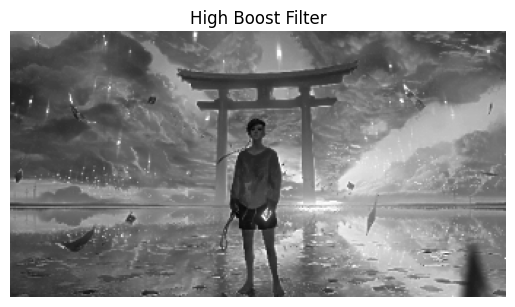

In [29]:
blur = cv2.GaussianBlur(img,(5,5),0)

mask = cv2.subtract(img,blur)

highboost = cv2.add(img,mask)

plt.imshow(highboost,cmap='gray')
plt.title("High Boost Filter")
plt.axis('off')
plt.show()

# Q9: Ideal Low-Pass Filtering

Objective:
To remove high-frequency components using an ideal low-pass filter.

Procedure:
1. Compute Fourier Transform.
2. Design LPF mask.
3. Apply filter.
4. Perform inverse transform.

Output:
Filtered image and frequency response.

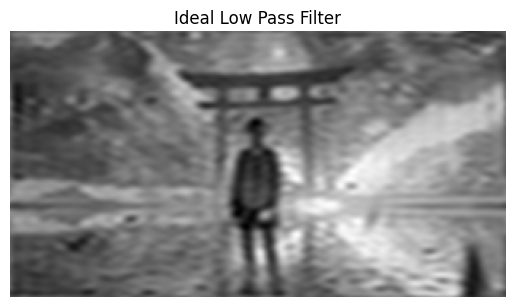

In [28]:
f = np.fft.fft2(img)
fshift = np.fft.fftshift(f)

rows, cols = img.shape
crow, ccol = rows//2, cols//2

mask = np.zeros((rows,cols))
mask[crow-30:crow+30, ccol-30:ccol+30] = 1

filtered = fshift * mask

result = np.abs(
    np.fft.ifft2(
        np.fft.ifftshift(filtered)
    )
)

plt.imshow(result,cmap='gray')
plt.title("Ideal Low Pass Filter")
plt.axis('off')
plt.show()

# Q10: Gaussian High-Pass Filtering

Objective:
To emphasize edges using a Gaussian high-pass filter.

Procedure:
1. Compute FFT.
2. Create Gaussian HPF.
3. Apply filter.
4. Perform inverse FFT.

Output:
Edge-enhanced image.

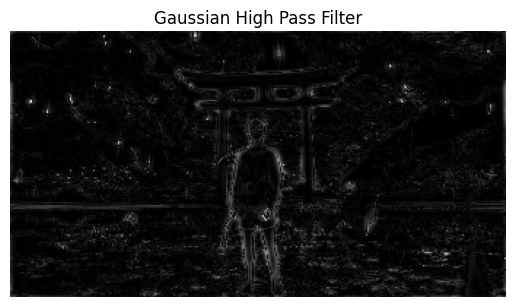

In [27]:
rows, cols = img.shape
crow, ccol = rows//2, cols//2

u,v = np.ogrid[:rows,:cols]

D = np.sqrt((u-crow)**2 + (v-ccol)**2)

D0 = 30

hpf = 1 - np.exp(-(D**2)/(2*(D0**2)))

f = np.fft.fft2(img)
fshift = np.fft.fftshift(f)

filtered = fshift * hpf

result = np.abs(
    np.fft.ifft2(
        np.fft.ifftshift(filtered)
    )
)

plt.imshow(result,cmap='gray')
plt.title("Gaussian High Pass Filter")
plt.axis('off')
plt.show()

# Q11: Point Detection Using Laplacian Mask

Objective:
To detect isolated points in an image.

Procedure:
1. Apply Laplacian mask.
2. Threshold response.
3. Identify points.

Output:
Detected point locations.

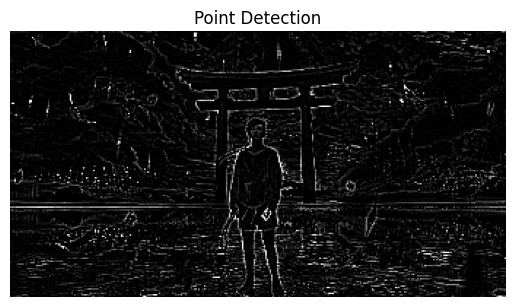

In [26]:
kernel = np.array([
[-1,-1,-1],
[-1, 8,-1],
[-1,-1,-1]
])

points = cv2.filter2D(img,-1,kernel)

plt.imshow(points,cmap='gray')
plt.title("Point Detection")
plt.axis('off')
plt.show()

# Q12: Line Detection Using Directional Masks

Objective:
To detect horizontal, vertical and diagonal lines.

Procedure:
1. Apply horizontal mask.
2. Apply vertical mask.
3. Apply diagonal mask.
4. Compare responses.

Output:
Detected line structures.

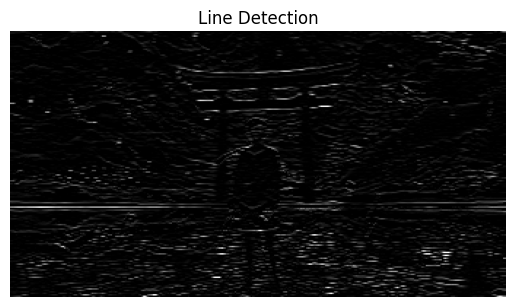

In [25]:
kernel = np.array([
[-1,-1,-1],
[ 2, 2, 2],
[-1,-1,-1]
])

lines = cv2.filter2D(img,-1,kernel)

plt.imshow(lines,cmap='gray')
plt.title("Line Detection")
plt.axis('off')
plt.show()

# Q13: Global Thresholding Using Otsu's Method

Objective:
To automatically determine an optimal threshold value.

Procedure:
1. Compute histogram.
2. Calculate between-class variance.
3. Select optimal threshold.
4. Segment image.

Output:
Threshold value and binary image.

Threshold Value = 152.0


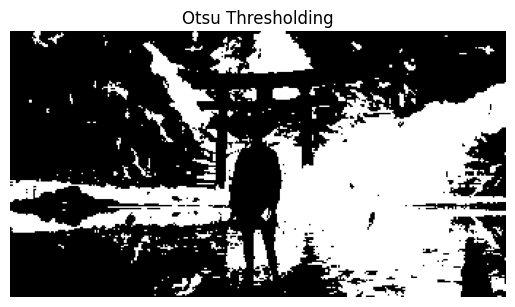

In [24]:
th,binary = cv2.threshold(
    img,
    0,
    255,
    cv2.THRESH_BINARY + cv2.THRESH_OTSU
)

print("Threshold Value =", th)

plt.imshow(binary,cmap='gray')
plt.title("Otsu Thresholding")
plt.axis('off')
plt.show()

# Q14: Region Growing Segmentation

Objective:
To segment an image starting from a seed pixel.

Procedure:
1. Select seed point.
2. Check neighbouring pixels.
3. Grow region based on similarity.
4. Generate segmented region.

Output:
Segmented image and region pixels.

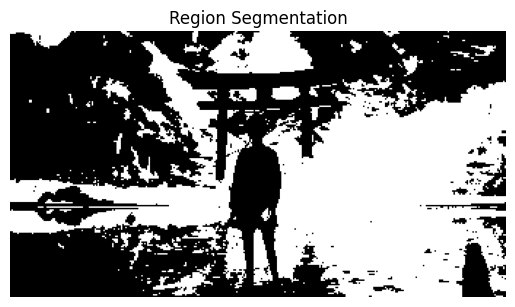

In [23]:
mean_val = np.mean(img)

region = np.where(img > mean_val,255,0)

plt.imshow(region,cmap='gray')
plt.title("Region Segmentation")
plt.axis('off')
plt.show()

# Q15: Edge Linking Using Hough Transform

Objective:
To connect fragmented edges using Hough-based processing.

Procedure:
1. Detect edges.
2. Apply Hough Transform.
3. Identify line parameters.
4. Link edge segments.

Output:
Linked edges and detected lines.

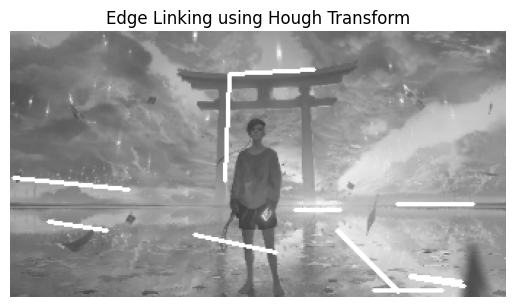

In [22]:
edges = cv2.Canny(img,100,200)

lines = cv2.HoughLinesP(
    edges,
    1,
    np.pi/180,
    threshold=50,
    minLineLength=30,
    maxLineGap=10
)

output = cv2.cvtColor(img,cv2.COLOR_GRAY2BGR)

if lines is not None:
    for line in lines:
        x1,y1,x2,y2 = line[0]
        cv2.line(output,(x1,y1),(x2,y2),(255,255,255),2)

plt.imshow(cv2.cvtColor(output,cv2.COLOR_BGR2RGB))
plt.title("Edge Linking using Hough Transform")
plt.axis('off')
plt.show()